In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/loan_prediction_dataset.csv')
df.head(10)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
5,25,64859,600,31005,36,Employed,0
6,38,73625,642,7638,24,Employed,0
7,56,72098,730,38419,36,Self-Employed,0
8,36,35251,723,34377,36,Employed,0
9,40,142413,631,41708,60,Employed,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2000 non-null   int64
 1   Income             2000 non-null   int64
 2   Credit_Score       2000 non-null   int64
 3   Loan_Amount        2000 non-null   int64
 4   Loan_Term          2000 non-null   int64
 5   Employment_Status  2000 non-null   str  
 6   Loan_Approved      2000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 109.5 KB


In [4]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [5]:
df.dtypes

Age                  int64
Income               int64
Credit_Score         int64
Loan_Amount          int64
Loan_Term            int64
Employment_Status      str
Loan_Approved        int64
dtype: object

In [6]:
df.shape

(2000, 7)

In [7]:
df.columns

Index(['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term',
       'Employment_Status', 'Loan_Approved'],
      dtype='str')

In [8]:
df.isna().sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [9]:
df['Loan_Approved'].value_counts()

Loan_Approved
0    1658
1     342
Name: count, dtype: int64

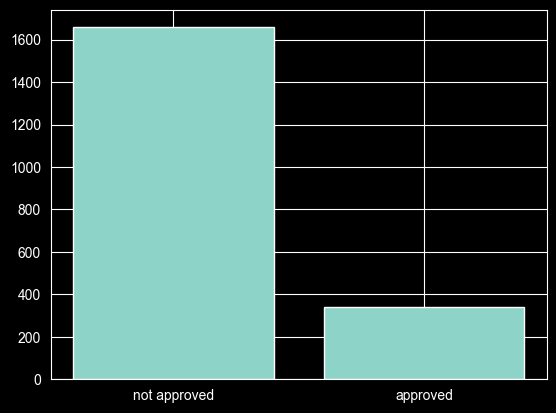

In [10]:
loan_count = df['Loan_Approved'].value_counts()
plt.bar(['not approved','approved'], loan_count)
plt.show()

In [11]:
df['Employment_Status'].value_counts()

Employment_Status
Employed         1260
Unemployed        375
Self-Employed     365
Name: count, dtype: int64

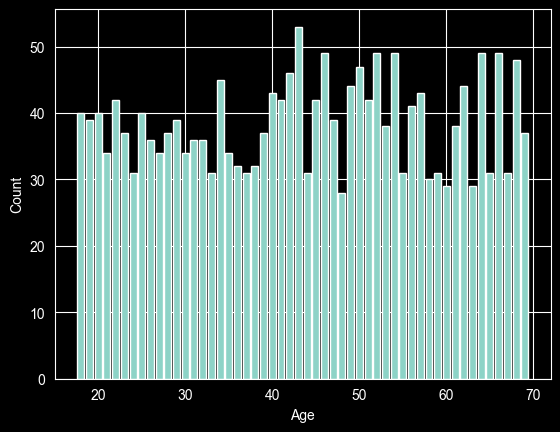

In [12]:
age_count = df['Age'].value_counts().sort_index()

plt.bar(age_count.index, age_count.values)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [13]:
young_ppl = df[df['Age']<30]
young_ppl.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,23.418708,81412.681514,576.316258,25639.389755,34.904232,0.151448
std,3.494665,38143.124135,158.580359,14565.235164,17.282635,0.358885
min,18.000000,20526.000000,302.000000,1240.000000,12.000000,0.000000
25%,20.000000,47766.000000,437.000000,11828.000000,24.000000,0.000000
50%,23.000000,80428.000000,572.000000,26363.000000,36.000000,0.000000
75%,26.000000,114788.000000,724.000000,38425.000000,48.000000,0.000000
max,29.000000,149295.000000,848.000000,49849.000000,60.000000,1.000000


In [14]:
big_loan_before_30 = df[(df['Age']<30) & (df["Loan_Amount"]>30000)]
big_loan_before_30["Loan_Approved"].value_counts()

Loan_Approved
0    195
Name: count, dtype: int64

In [15]:
loan_approve_by_income = df.groupby('Loan_Approved')[["Income", "Age"]].mean()
loan_approve_by_income

,Income,Age
Loan_Approved,,
0,81410.389626,43.454162
1,99674.690058,45.508772


In [16]:
df["Employment_Status"].value_counts()

Employment_Status
Employed         1260
Unemployed        375
Self-Employed     365
Name: count, dtype: int64

In [17]:
df["Employment_Status"].unique()

<StringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str